## Setup

In [35]:
import sys
from pathlib import Path

project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [36]:
import importlib
import inspect
import src.models as models

importlib.invalidate_caches()
models = importlib.reload(models)

print(inspect.signature(models.MultimodalClassifier))

(tabular_dim: 'int', text_dim: 'int' = 384, tabular_hidden_dim: 'int' = 32, tabular_output_dim: 'int' = 16, text_hidden_dim: 'int' = 32, text_output_dim: 'int' = 8, fusion_hidden_dim: 'int' = 16, tabular_dropout: 'float' = 0.3, text_dropout: 'float' = 0.5, fusion_dropout: 'float' = 0.3) -> 'None'


In [37]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch import nn
from torch.utils.data import DataLoader
from src.data_processing import chronological_split
from src.datasets import MultimodalMovieDataset
from src.evaluation import evaluate_classifier
from src.models import MultimodalClassifier
from src.training import (
    count_trainable_parameters,
    fit_multimodal_classifier,
    predict_multimodal_classifier,
    set_random_seed,
)

In [3]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Using device:", device)

Using device: mps


In [39]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

df = pd.read_csv(
    project_root / "data/processed/movies_processed.csv",
    parse_dates=["release_date"],
)

synopsis_embeddings = np.load(
    project_root / "data/processed/synopsis_embeddings.npy"
)

# Preserve alignment with synopsis_embeddings
df = df.copy()
df["_embedding_row"] = np.arange(len(df))

if len(df) != len(synopsis_embeddings):
    raise ValueError(
        "The number of movies and synopsis embeddings does not match."
    )

# Newest movies remain the chronological test set
development = df[
    df["release_year"] < 2014
].copy()

test = df[
    df["release_year"] >= 2014
].copy()

# Random validation split within the earlier development period
train, validation = train_test_split(
    development,
    test_size=185,
    stratify=development["flop"],
    random_state=42,
)

# Optional index cleanup; _embedding_row still preserves alignment
train = train.reset_index(drop=True)
validation = validation.reset_index(drop=True)
test = test.reset_index(drop=True)

print("Dataframe:", df.shape)
print("Embeddings:", synopsis_embeddings.shape)
print("Train:", len(train))
print("Validation:", len(validation))
print("Test:", len(test))

print("\nFlop proportions:")
print("Train:", train["flop"].mean())
print("Validation:", validation["flop"].mean())
print("Test:", test["flop"].mean())

assert len(train) == 559
assert len(validation) == 185
assert len(test) == 113

Dataframe: (857, 57)
Embeddings: (857, 384)
Train: 559
Validation: 185
Test: 113

Flop proportions:
Train: 0.5813953488372093
Validation: 0.5783783783783784
Test: 0.40707964601769914


In [40]:
x_text_train = synopsis_embeddings[
    train["_embedding_row"].to_numpy()
].astype(np.float32)

x_text_validation = synopsis_embeddings[
    validation["_embedding_row"].to_numpy()
].astype(np.float32)

x_text_test = synopsis_embeddings[
    test["_embedding_row"].to_numpy()
].astype(np.float32)

In [41]:
# feature extraction
genre_features = [
    column
    for column in df.columns
    if column.startswith("genre_")
]
numeric_features = [
    "budget",
    "runtime",
    "director_success_ratio",
    "director_prior_count",
    "actor_success_ratio",
    "actor_prior_count",
    "is_sequel_or_remake",
    "major_studio",
    *genre_features,
]
categorical_features = [
    "original_language",
    "release_season",
]
features = numeric_features + categorical_features
target = "flop"

In [42]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ]
)

In [43]:
# tabular data
x_tabular_train = preprocessor.fit_transform(
    train[features]
).astype(np.float32)

x_tabular_validation = preprocessor.transform(
    validation[features]
).astype(np.float32)

y_train = train[target].to_numpy(dtype=np.float32)
y_validation = validation[target].to_numpy(dtype=np.float32)

print("Tabular train shape:", x_tabular_train.shape)
print("Tabular validation shape:", x_tabular_validation.shape)

Tabular train shape: (559, 37)
Tabular validation shape: (185, 37)


In [44]:
# text data
x_text_train = synopsis_embeddings[
    train["_embedding_row"].to_numpy()
].astype(np.float32)

x_text_validation = synopsis_embeddings[
    validation["_embedding_row"].to_numpy()
].astype(np.float32)

print("Text train shape:", x_text_train.shape)
print("Text validation shape:", x_text_validation.shape)

Text train shape: (559, 384)
Text validation shape: (185, 384)


In [45]:
# create datasets and loaders
multimodal_train_dataset = MultimodalMovieDataset(
    tabular_features=x_tabular_train,
    text_embeddings=x_text_train,
    labels=y_train)
multimodal_validation_dataset = MultimodalMovieDataset(
    tabular_features=x_tabular_validation,
    text_embeddings=x_text_validation,
    labels=y_validation)

In [46]:
set_random_seed(1024)
loader_generator = torch.Generator()
loader_generator.manual_seed(1024)
multimodal_train_loader = DataLoader(
    multimodal_train_dataset,
    batch_size=32,
    shuffle=True,
    generator=loader_generator)
multimodal_validation_loader = DataLoader(
    multimodal_validation_dataset,
    batch_size=64,
    shuffle=False)

## Create and Train model

In [47]:
set_random_seed(1024)

multimodal_model = models.MultimodalClassifier(
    tabular_dim=x_tabular_train.shape[1],  # 37
    text_dim=x_text_train.shape[1],        # 384

    tabular_hidden_dim=16,
    tabular_output_dim=8,

    text_hidden_dim=8,
    text_output_dim=4,

    fusion_hidden_dim=8,

    tabular_dropout=0.4,
    text_dropout=0.5,
    fusion_dropout=0.5,
)

print(multimodal_model)

parameter_count = count_trainable_parameters(
    multimodal_model
)

print("Trainable parameters:", parameter_count)

MultimodalClassifier(
  (tabular_encoder): Sequential(
    (0): Linear(in_features=37, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=16, out_features=8, bias=True)
    (4): ReLU()
  )
  (text_encoder): Sequential(
    (0): Linear(in_features=384, out_features=8, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=8, out_features=4, bias=True)
    (4): ReLU()
  )
  (fusion_network): Sequential(
    (0): Linear(in_features=12, out_features=8, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=8, out_features=1, bias=True)
  )
)
Trainable parameters: 3973


In [48]:
loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    multimodal_model.parameters(),
    lr=1e-3,
    weight_decay=1e-3)

In [49]:
multimodal_history = fit_multimodal_classifier(
    model=multimodal_model,
    train_loader=multimodal_train_loader,
    validation_loader=multimodal_validation_loader,
    optimizer=optimizer,
    loss_function=loss_function,
    device=device,
    max_epochs=100,
    patience=12)
best_epoch = (
    np.argmin(multimodal_history["validation_loss"]) + 1)
print(
    "Epochs trained:",
    multimodal_history["epochs_trained"])
print("Best epoch:", best_epoch)
print(
    "Best validation loss:",
    multimodal_history["best_validation_loss"])

Epochs trained: 43
Best epoch: 31
Best validation loss: 0.6048872928361635


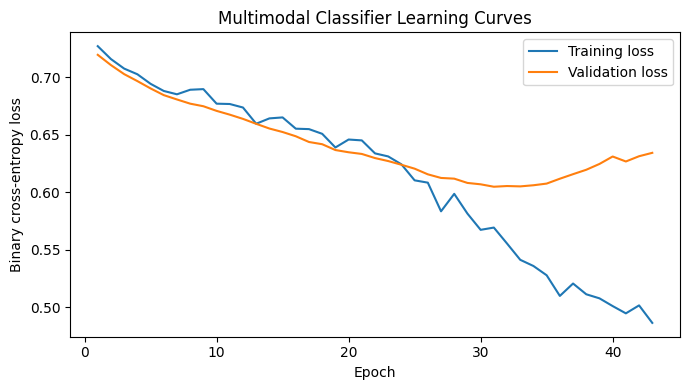

In [50]:
epochs = np.arange(
    1,
    multimodal_history["epochs_trained"] + 1)

plt.figure(figsize=(7, 4))
plt.plot(
    epochs,
    multimodal_history["train_loss"],
    label="Training loss")
plt.plot(
    epochs,
    multimodal_history["validation_loss"],
    label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("Multimodal Classifier Learning Curves")
plt.legend()
plt.tight_layout()
plt.show()

In [51]:
multimodal_validation_pred, multimodal_validation_prob = (
    predict_multimodal_classifier(
        model=multimodal_model,
        loader=multimodal_validation_loader,
        device=device,
    )
)

multimodal_metrics = evaluate_classifier(
    y_true=y_validation.astype(int),
    y_pred=multimodal_validation_pred,
    y_prob=multimodal_validation_prob,
)

multimodal_metrics

{'accuracy': 0.6756756756756757,
 'balanced_accuracy': 0.6570812365204888,
 'flop_precision': 0.6974789915966386,
 'flop_recall': 0.7757009345794392,
 'flop_f1': 0.7345132743362832,
 'roc_auc': 0.7189072609633357}

In [54]:
print(
    np.unique(
        multimodal_validation_pred,
        return_counts=True,
    )
)

print(
    "Probability range:",
    multimodal_validation_prob.min(),
    multimodal_validation_prob.max(),
)

(array([0, 1]), array([ 66, 119]))
Probability range: 0.26157007 0.95722055


In [55]:
seeds = [0, 1, 2, 3, 4]
multimodal_results = []

for seed in seeds:
    set_random_seed(seed)

    generator = torch.Generator()
    generator.manual_seed(seed)

    train_loader = DataLoader(
        multimodal_train_dataset,
        batch_size=32,
        shuffle=True,
        generator=generator,
    )

    validation_loader = DataLoader(
        multimodal_validation_dataset,
        batch_size=64,
        shuffle=False,
    )

    model = models.MultimodalClassifier(
        tabular_dim=x_tabular_train.shape[1],
        text_dim=x_text_train.shape[1],
        tabular_hidden_dim=16,
        tabular_output_dim=8,
        text_hidden_dim=8,
        text_output_dim=4,
        fusion_hidden_dim=8,
        tabular_dropout=0.4,
        text_dropout=0.5,
        fusion_dropout=0.5,
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-3,
        weight_decay=1e-3,
    )

    history = fit_multimodal_classifier(
        model=model,
        train_loader=train_loader,
        validation_loader=validation_loader,
        optimizer=optimizer,
        loss_function=nn.BCEWithLogitsLoss(),
        device=device,
        max_epochs=100,
        patience=12,
    )

    predictions, probabilities = (
        predict_multimodal_classifier(
            model=model,
            loader=validation_loader,
            device=device,
        )
    )

    metrics = evaluate_classifier(
        y_true=y_validation.astype(int),
        y_pred=predictions,
        y_prob=probabilities,
    )

    multimodal_results.append(
        {
            "seed": seed,
            "best_epoch": (
                np.argmin(history["validation_loss"]) + 1
            ),
            "epochs_trained": history["epochs_trained"],
            "best_validation_loss": history[
                "best_validation_loss"
            ],
            **metrics,
        }
    )

In [56]:
multimodal_results_df = pd.DataFrame(
    multimodal_results
)

display(multimodal_results_df.round(3))

,seed,best_epoch,epochs_trained,best_validation_loss,accuracy,balanced_accuracy,flop_precision,flop_recall,flop_f1,roc_auc
0,0,27,39,0.631,0.659,0.634,0.675,0.794,0.730,0.690
1,1,28,40,0.624,0.638,0.617,0.667,0.748,0.705,0.693
2,2,53,65,0.606,0.681,0.651,0.682,0.841,0.753,0.688
3,3,22,34,0.635,0.659,0.624,0.659,0.850,0.743,0.686
4,4,24,36,0.630,0.665,0.637,0.674,0.813,0.737,0.687


In [57]:
multimodal_summary = multimodal_results_df[
    [
        "accuracy",
        "balanced_accuracy",
        "flop_precision",
        "flop_recall",
        "flop_f1",
        "roc_auc",
        "best_epoch",
    ]
].agg(["mean", "std"])

display(multimodal_summary.round(3))

,accuracy,balanced_accuracy,flop_precision,flop_recall,flop_f1,roc_auc,best_epoch
mean,0.661,0.633,0.671,0.809,0.734,0.689,30.800
std,0.015,0.013,0.009,0.041,0.018,0.003,12.637


## Two Head Model

In [61]:
import importlib

import src.datasets as datasets
import src.models as models
import src.training as training

importlib.invalidate_caches()

datasets = importlib.reload(datasets)
models = importlib.reload(models)
training = importlib.reload(training)

In [62]:
print(x_tabular_train.shape)
print(x_tabular_validation.shape)
print(y_train.shape)
print(y_validation.shape)

(559, 37)
(185, 37)
(559,)
(185,)


In [63]:
train_log_ratio = np.log1p(
    train["rev_budget_ratio"]
    .clip(upper=10)
    .to_numpy(dtype=np.float32)
)

validation_log_ratio = np.log1p(
    validation["rev_budget_ratio"]
    .clip(upper=10)
    .to_numpy(dtype=np.float32)
)

In [64]:
ratio_mean = train_log_ratio.mean()
ratio_std = train_log_ratio.std()

if ratio_std == 0:
    raise ValueError(
        "The training return-ratio target has zero variance."
    )

train_ratio_scaled = (
    train_log_ratio - ratio_mean
) / ratio_std

validation_ratio_scaled = (
    validation_log_ratio - ratio_mean
) / ratio_std

In [65]:
print("Training ratio mean:", train_ratio_scaled.mean())
print("Training ratio std:", train_ratio_scaled.std())
print("Validation shape:", validation_ratio_scaled.shape)

Training ratio mean: -3.4120728e-08
Training ratio std: 0.99999994
Validation shape: (185,)


In [66]:
multitask_train_dataset = (
    datasets.MultiTaskMovieDataset(
        features=x_tabular_train,
        flop_labels=y_train,
        ratio_targets=train_ratio_scaled,
    )
)

multitask_validation_dataset = (
    datasets.MultiTaskMovieDataset(
        features=x_tabular_validation,
        flop_labels=y_validation,
        ratio_targets=validation_ratio_scaled,
    )
)

AttributeError: module 'src.datasets' has no attribute 'MultiTaskMovieDataset'

In [ ]:
set_random_seed(42)

generator = torch.Generator()
generator.manual_seed(42)

multitask_train_loader = DataLoader(
    multitask_train_dataset,
    batch_size=32,
    shuffle=True,
    generator=generator,
)

multitask_validation_loader = DataLoader(
    multitask_validation_dataset,
    batch_size=64,
    shuffle=False,
)

In [ ]:
multitask_model = models.MultiTaskTabularMLP(
    input_dim=x_tabular_train.shape[1],
    hidden_dims=(64, 32),
    dropout=0.3,
)

print(multitask_model)
print(
    "Trainable parameters:",
    count_trainable_parameters(multitask_model),
)

In [ ]:
classification_loss_function = (
    nn.BCEWithLogitsLoss()
)

regression_loss_function = (
    nn.SmoothL1Loss()
)

optimizer = torch.optim.Adam(
    multitask_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

In [ ]:
regression_weight = 0.3

history = training.fit_multitask_model(
    model=multitask_model,
    train_loader=multitask_train_loader,
    validation_loader=multitask_validation_loader,
    optimizer=optimizer,
    classification_loss_function=(
        classification_loss_function
    ),
    regression_loss_function=(
        regression_loss_function
    ),
    regression_weight=regression_weight,
    device=device,
    max_epochs=100,
    patience=12,
)

print("Epochs trained:", history["epochs_trained"])

print(
    "Best epoch:",
    np.argmin(
        history["validation_total_loss"]
    ) + 1,
)

print(
    "Best validation loss:",
    history["best_validation_loss"],
)

In [ ]:
epochs = np.arange(
    1,
    history["epochs_trained"] + 1,
)

plt.figure(figsize=(7, 4))

plt.plot(
    epochs,
    history["train_total_loss"],
    label="Training total loss",
)

plt.plot(
    epochs,
    history["validation_total_loss"],
    label="Validation total loss",
)

plt.xlabel("Epoch")
plt.ylabel("Combined loss")
plt.title("Multi-Task Tabular Model")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
(
    validation_predictions,
    validation_probabilities,
    validation_ratio_scaled_pred,
) = training.predict_multitask_model(
    model=multitask_model,
    loader=multitask_validation_loader,
    device=device,
)

In [ ]:
classification_metrics = evaluate_classifier(
    y_true=y_validation.astype(int),
    y_pred=validation_predictions,
    y_prob=validation_probabilities,
)

classification_metrics

In [ ]:
validation_log_ratio_pred = (
    validation_ratio_scaled_pred * ratio_std
    + ratio_mean
)

validation_ratio_pred = np.expm1(
    validation_log_ratio_pred
)

validation_ratio_pred = np.clip(
    validation_ratio_pred,
    0,
    10,
)

validation_ratio_true = (
    validation["rev_budget_ratio"]
    .clip(upper=10)
    .to_numpy(dtype=np.float32)
)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)

ratio_mae = mean_absolute_error(
    validation_ratio_true,
    validation_ratio_pred,
)

ratio_rmse = mean_squared_error(
    validation_ratio_true,
    validation_ratio_pred,
) ** 0.5

print("Capped return-ratio MAE:", ratio_mae)
print("Capped return-ratio RMSE:", ratio_rmse)

## Tabular experiments